In [1]:
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", True)

import pickle
import datagen
import pandas as pd
import numpy as np
import jax.numpy as jnp
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from time import time
from functools import partial
from rebayes_mini import callbacks
from bayes_opt import BayesianOptimization
from rebayes_mini.methods import student_t_filter as stf
from rebayes_mini.methods import gauss_filter as kf
from rebayes_mini.methods import robust_filter as rkf
#from rebayes_mini.methods import generalised_bayes_filter as gbf

from profilter import ExtendedKalmanFilter
from unscented import UnscentedKalmanFilter

In [2]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

plt.rcParams["font.size"] = 18
cmap = {
    "KF-IW": "crimson",
    "KF": "lightseagreen",
    "WoLF-IMQ": "dodgerblue",
    "WoLF-MD": "gold",
    "KF-B": "darkorange",
    "KF-PrO": "mediumorchid",
}

In [3]:
delta = 0.1
dynamics_covariance = 0.1
obs_covariance = 10.0
B1 = jnp.array([0, 0, 0, 0])
B2 = jnp.array([-1.225, -0.35, 1.225, 0.35])
B3 = jnp.array([1.225, 0.35,  -1.225,  -0.35])
B = jnp.stack([B1, B2, B3], axis=1)

In [4]:
#name_dgen = "irregular_grid"
#name_dgen = "student_dynamic"
#name_dgen = "student_obs"
#name_dgen = "well_specified"
name_dgen = "well_specified"

match name_dgen:
    case "student_obs":
        dgen = datagen.GaussStMovingObject2D(
            delta, dynamics_covariance, obs_covariance,
            dof_observed=2.01
        )
    case "mean":
        dgen = datagen.GaussMeanOutlierMovingObject2D(
            delta, dynamics_covariance, obs_covariance,
            outlier_proba=0.05,
            outlier_scale=2.0,
        )
    case "added_mean":
        dgen = datagen.GaussOneSideOutlierMovingObject2D(
            delta, dynamics_covariance, obs_covariance,
            outlier_proba=0.05,
            outlier_minval=-100,
            outlier_maxval=100
        )
    case "irregular_grid":
        dgen = datagen.MovingObject2DIrregular(
            delta, dynamics_covariance, obs_covariance,
        )
    case "well_specified":
        dgen = datagen.MovingObject2D(
            delta, dynamics_covariance, obs_covariance,
        )
    case "student_dynamic":
        dgen = datagen.GaussStMovingObject2D_dynamic(
            delta, dynamics_covariance, obs_covariance,
            dof_observed=3.0,
        )
    case "maneuver":
        dgen = datagen.Maneuvering2D(
            delta, dynamics_covariance, obs_covariance, B=B, transition_prob=0.99,
        )
    case _:
        raise ValueError(f"Dgen {name_dgen} not valid")

key = jax.random.PRNGKey(314)
initial_mean = jnp.array([0.0, 0.0, 1.0, 1.0])

if name_dgen == "maneuver":
    initial_mean = (initial_mean, int(0))

In [5]:
n_steps = 500
n_samples = 15
keys = jax.random.split(key, n_samples)

colors = plt.cm.viridis(jnp.linspace(0, 1, n_samples))
datasets = jax.vmap(dgen.sample, in_axes=(0, None, None))(keys, initial_mean, n_steps)

yv = datasets["observed"]
if name_dgen == "maneuver":
    statev = datasets["latent"][0]
else:
    statev = datasets["latent"]

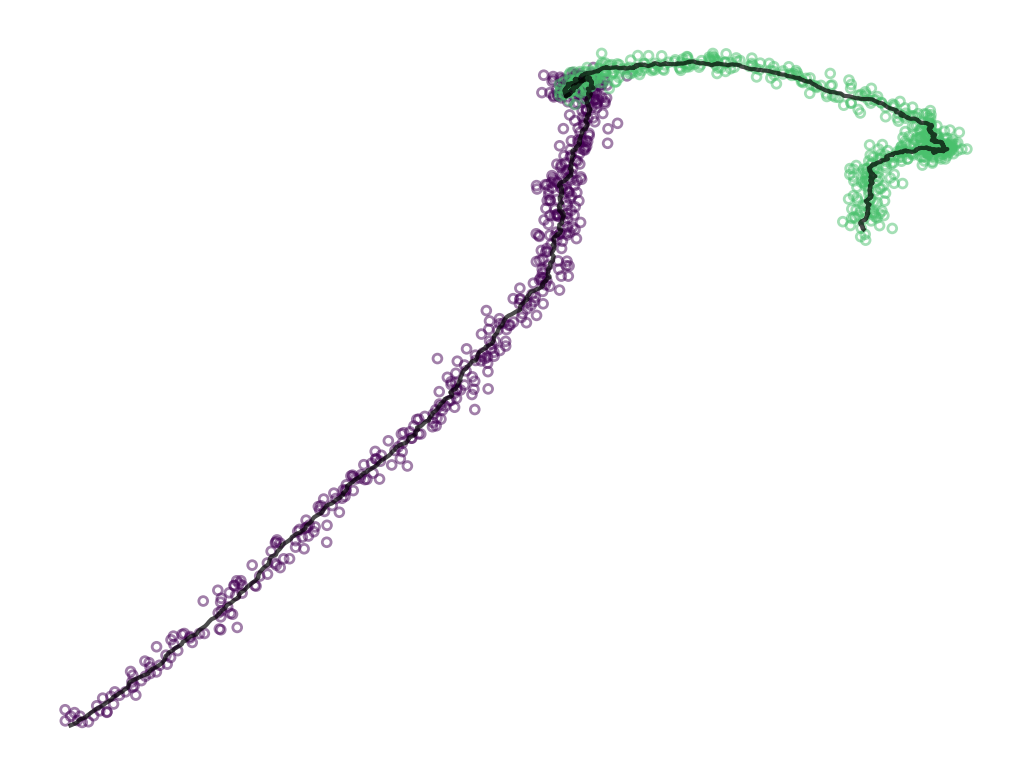

In [6]:
datasets_cpu = jax.tree_util.tree_map(lambda x: np.array(x[::10]), datasets)
for i, color in enumerate(colors[::10]):
    dataset = jax.tree_util.tree_map(lambda x: x[i], datasets_cpu)
    if name_dgen == "maneuver":
        plt.plot(*dataset["latent"][0][:, :2].T, c="black", alpha=0.7)
    else:
        plt.plot(*dataset["latent"][:, :2].T, c="black", alpha=0.7)
    plt.scatter(*dataset["observed"].T, edgecolor=color, color="none", s=10, alpha=0.5)
    
plt.axis("off");
plt.savefig("trajectories_student.png", bbox_inches='tight')

In [7]:
if name_dgen == "maneuver":
    initial_mean = initial_mean[0]

def latent_fn(z):
    return dgen.transition_matrix @ z

def measurement_fn(z, _):
    return dgen.projection_matrix @ z

In [8]:
time_methods = {}
hist_methods = {}
configs = {}

# KF

In [9]:
@jax.jit
def filter_kf(measurements, state):
    nsteps = len(measurements)
    agent_imq = rkf.ExtendedKalmanFilterIMQ(
        latent_fn, measurement_fn,
        dynamics_covariance=dgen.dynamics_covariance,
        observation_covariance=dgen.observation_covariance,
        soft_threshold=1e8,
    )
    
    init_bel = agent_imq.init_bel(initial_mean, cov=1.0)
    filterfn = partial(agent_imq.scan, callback_fn=callbacks.get_updated_mean)
    _, hist = filterfn(init_bel, measurements, jnp.ones(n_steps))

    err = jnp.sqrt(jnp.power(hist - state, 2).sum(axis=0))
    return err, hist

In [10]:
method = "KF"

hist_bel = []
times = []

for y, state in tqdm(zip(yv, statev), total=n_samples): 
    tinit = time()
    _, run = filter_kf(y, state)
    tend = time()
    
    hist_bel.append(run)
    times.append(tend - tinit)

hist_bel = np.stack(hist_bel)

hist_methods[method] = hist_bel
time_methods[method] = times

100%|██████████| 15/15 [00:00<00:00, 35.87it/s]


# EKF (plain, for UKF comparison)

In [11]:
@jax.jit
def filter_ekf_plain(measurements, state):
    agent_ekf = ExtendedKalmanFilter(
        latent_fn, measurement_fn,
        dynamics_covariance=dgen.dynamics_covariance,
        observation_covariance=dgen.observation_covariance,
    )
    init_bel = agent_ekf.init_bel(initial_mean, cov=1.0)
    filterfn = partial(agent_ekf.scan, callback_fn=callbacks.get_updated_mean)
    _, hist = filterfn(init_bel, measurements, jnp.ones(n_steps))
    err = jnp.sqrt(jnp.power(hist - state, 2).sum(axis=0))
    return err, hist

In [12]:
method = "EKF-plain"
hist_bel = []
times = []
for y, state in tqdm(zip(yv, statev), total=n_samples):
    tinit = time()
    _, run = filter_ekf_plain(y, state)
    tend = time()
    hist_bel.append(run)
    times.append(tend - tinit)
hist_bel = np.stack(hist_bel)
hist_methods[method] = hist_bel
time_methods[method] = times

100%|██████████| 15/15 [00:00<00:00, 62.27it/s]


# UKF

In [13]:
@jax.jit
def filter_ukf(measurements, state):
    nsteps = len(measurements)
    agent_ukf = UnscentedKalmanFilter(
        latent_fn, measurement_fn,
        dynamics_covariance=dgen.dynamics_covariance,
        observation_covariance=dgen.observation_covariance,
    )

    init_bel = agent_ukf.init_bel(initial_mean, cov=1.0)
    filterfn = partial(agent_ukf.scan, callback_fn=callbacks.get_updated_mean)
    _, hist = filterfn(init_bel, measurements, jnp.ones(n_steps))

    err = jnp.sqrt(jnp.power(hist - state, 2).sum(axis=0))
    return err, hist

In [14]:
method = "UKF"

hist_bel = []
times = []

for y, state in tqdm(zip(yv, statev), total=n_samples):
    tinit = time()
    _, run = filter_ukf(y, state)
    tend = time()

    hist_bel.append(run)
    times.append(tend - tinit)

hist_bel = np.stack(hist_bel)

hist_methods[method] = hist_bel
time_methods[method] = times

100%|██████████| 15/15 [00:00<00:00, 47.03it/s]


In [15]:
print("Max diff (EKF-plain vs UKF):", np.max(np.abs(hist_methods["EKF-plain"] - hist_methods["UKF"])))
print("Mean diff (EKF-plain vs UKF):", np.mean(np.abs(hist_methods["EKF-plain"] - hist_methods["UKF"])))

Max diff (EKF-plain vs UKF): 1.466626038393315e-07
Mean diff (EKF-plain vs UKF): 7.241869927902388e-09


# PrO-KF

In [16]:
from profilter_rebuttal import PrOFilter

@jax.jit
def filter_prokf(n_inner, n_outer, measurements, state):
    nsteps = len(measurements)
    agent_pro = PrOFilter(
        latent_fn, measurement_fn,
        dynamics_covariance=dgen.dynamics_covariance,
        observation_covariance=dgen.observation_covariance,
        n_inner=n_inner,
        n_outer=n_outer
    )
    
    init_bel = agent_pro.init_bel(initial_mean, cov=1.0)
    filterfn = partial(agent_pro.scan, callback_fn=callbacks.get_updated_mean)
    _, hist = filterfn(init_bel, measurements, jnp.ones(n_steps))

    err = jnp.sqrt(jnp.power(hist - state, 2)[:, :2].sum(axis=0))
    return err, hist


@jax.jit
def bo_filter_prokf(n_inner, n_outer):
    err, _ = filter_prokf(n_inner, n_outer, yv[0], statev[0])
    return -err.max()

In [17]:
bo = BayesianOptimization(
    bo_filter_prokf,
    pbounds={
        "n_inner": (1, 60, int),
        "n_outer":  (1, 60, int),
    },
    random_state=34,
    verbose=1
)
bo.maximize(init_points=20, n_iter=30)

/var/folders/r4/p062074s47bd8mh7y8k7qhy40000gn/T/ipykernel_50517/223014506.py:1: UserWarning: Non-float parameters are experimental and may not work as expected. Exercise caution when using them and please report any issues you encounter.
  bo = BayesianOptimization(


|   iter    |  target   |  n_inner  |  n_outer  |
-------------------------------------------------
| 26        | -29.93509 | 1         | 1         |


In [18]:
method = "KF-PrO"

n_inner = 60 #int(bo.max["params"]["n_inner"])
n_outer = 60 #int(bo.max["params"]["n_outer"])

hist_bel = []
times = []

for y, state in tqdm(zip(yv, statev), total=n_samples): 
    tinit = time()
    _, run = filter_prokf(n_inner, n_outer, y, state)
    tend = time()
    
    hist_bel.append(run)
    times.append(tend - tinit)

hist_bel = np.stack(hist_bel)

hist_methods[method] = hist_bel
time_methods[method] = times

100%|██████████| 15/15 [00:06<00:00,  2.40it/s]


# UKF-PrO

In [19]:
from unscented import UKFPrOFilter

@jax.jit
def filter_ukfpro(n_inner, n_outer, measurements, state):
    nsteps = len(measurements)
    agent_ukfpro = UKFPrOFilter(
        latent_fn, measurement_fn,
        dynamics_covariance=dgen.dynamics_covariance,
        observation_covariance=dgen.observation_covariance,
        n_inner=n_inner,
        n_outer=n_outer
    )
    
    init_bel = agent_ukfpro.init_bel(initial_mean, cov=1.0)
    filterfn = partial(agent_ukfpro.scan, callback_fn=callbacks.get_updated_mean)
    _, hist = filterfn(init_bel, measurements, jnp.ones(n_steps))

    err = jnp.sqrt(jnp.power(hist - state, 2)[:, :2].sum(axis=0))
    return err, hist


@jax.jit
def bo_filter_ukfpro(n_inner, n_outer):
    err, _ = filter_ukfpro(n_inner, n_outer, yv[0], statev[0])
    return -err.max()

In [20]:
bo_ukfpro = BayesianOptimization(
    bo_filter_ukfpro,
    pbounds={
        "n_inner": (1, 300, int),
        "n_outer":  (1, 1, int),
    },
    random_state=34,
    verbose=1
)
bo_ukfpro.maximize(init_points=20, n_iter=30)

/var/folders/r4/p062074s47bd8mh7y8k7qhy40000gn/T/ipykernel_50517/421801362.py:1: UserWarning: Non-float parameters are experimental and may not work as expected. Exercise caution when using them and please report any issues you encounter.
  bo_ukfpro = BayesianOptimization(


|   iter    |  target   |  n_inner  |  n_outer  |
-------------------------------------------------
| 8         | -30.24973 | 19        | 1         |


In [21]:
method = "UKF-PrO"

n_inner = 300 #int(bo_ukfpro.max["params"]["n_inner"])
n_outer = int(bo_ukfpro.max["params"]["n_outer"])

hist_bel = []
times = []

for y, state in tqdm(zip(yv, statev), total=n_samples): 
    tinit = time()
    _, run = filter_ukfpro(n_inner, n_outer, y, state)
    tend = time()
    
    hist_bel.append(run)
    times.append(tend - tinit)

hist_bel = np.stack(hist_bel)

hist_methods[method] = hist_bel
time_methods[method] = times

100%|██████████| 15/15 [00:15<00:00,  1.02s/it]


In [22]:
print("Max diff (KF-PrO vs UKF-PrO):", np.max(np.abs(hist_methods["KF-PrO"] - hist_methods["UKF-PrO"])))
print("Mean diff (KF-PrO vs UKF-PrO):", np.mean(np.abs(hist_methods["KF-PrO"] - hist_methods["UKF-PrO"])))

Max diff (KF-PrO vs UKF-PrO): 1.3409258912133737e-06
Mean diff (KF-PrO vs UKF-PrO): 1.9607072283359266e-07
